# Russian Sentiment Analysis Demo

This notebook demonstrates a complete end-to-end sentiment analysis workflow for Russian text:

- Text preprocessing (Russian-specific normalization and token handling)
- TF-IDF feature extraction
- Logistic Regression classifier with calibrated probabilities
- Single and batch sentiment predictions

### Classes:
- Negative
- Neutral
- Positive

### Environment Setup

In [1]:
from pathlib import Path  # Path handling
import pandas as pd  # Data handling

from preprocess_ru import preprocess_text  # Russian preprocessing pipeline
from predict_model import predict_sentiment, predict_proba, predict_batch_detailed  # Inference helpers

### Load Russian Dataset

In [2]:
# Resolve the classifier root robustly from common working directories.
candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "projects" / "sentiment_analysis" / "russian_classifier",
]

BASE_DIR = next((p for p in candidate_roots if (p / "data").exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError("Could not locate russian_classifier/data from current working directory.")

DATA_DIR = BASE_DIR / "data"
data_path = DATA_DIR / "train_ru.csv"

df = pd.read_csv(data_path, encoding="utf-8")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (166, 2)


,text,sentiment
0,Это просто нормально.,neutral
1,Потрясающая производительность и отличный дизайн.,positive
2,"Я жалею, что купил это.",negative
3,Это приемлемо для ежедневного использования.,neutral
4,Мне действительно нравится этим пользоваться.,positive


### Data Overview

C:\Users\Nikolai\AppData\Local\Temp\ipykernel_6968\3558776122.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


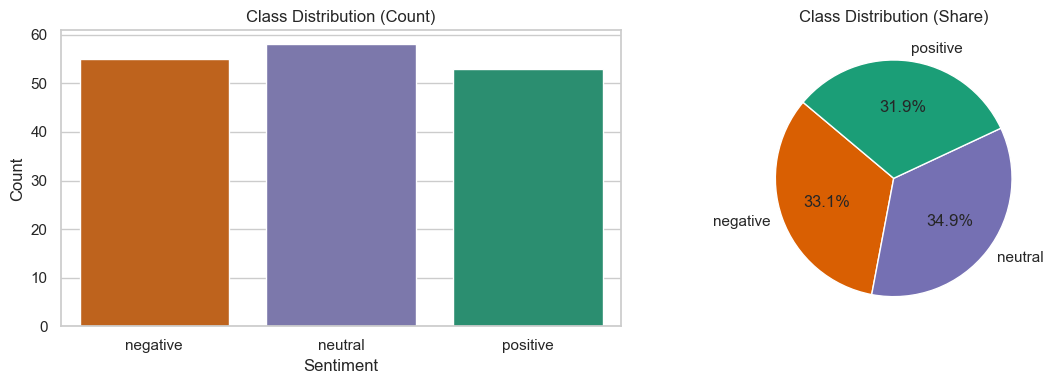

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid")

label_order = ["negative", "neutral", "positive"]
label_map_numeric = {0: "negative", 1: "neutral", 2: "positive"}

label_series = df["sentiment"].map(label_map_numeric).fillna(df["sentiment"].astype(str).str.lower())
class_counts = label_series.value_counts().reindex(label_order, fill_value = 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x = class_counts.index,
    y = class_counts.values,
    palette = ["#d95f02", "#7570b3", "#1b9e77"],
    ax = axes[0]
    )
axes[0].set_title("Class Distribution (Count)")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

axes[1].pie(
    class_counts.values,
    labels = class_counts.index,
    autopct = "%1.1f%%",
    colors = ["#d95f02", "#7570b3", "#1b9e77"],
    startangle = 140
    )
axes[1].set_title("Class Distribution (Share)")

plt.tight_layout()
plt.show()

In [4]:
# Display Class Distribution
print("Class Distribution:")
print(df["sentiment"].value_counts())

Class Distribution:
sentiment
neutral     58
negative    55
positive    53
Name: count, dtype: int64


### Preprocessing Demo

In [5]:
sample = "Я не могу поверить, насколько хорош этот продукт!"  # Sample Russian text
processed_text = preprocess_text(sample)  # Preprocess sample text

print(f"Original Text: {sample}")
print(f"\nProcessed Text: {processed_text}")

Original Text: Я не могу поверить, насколько хорош этот продукт!

Processed Text: не мочь поверить насколько хороший продукт


### Model Training Explanation

The model is trained in `train_model.py` with:

- TF-IDF vectorization (unigrams + bigrams)
- Logistic Regression classifier
- Calibrated probabilities for more meaningful confidence scores
- Stratified train/test split
- Label mapping:
  - negative -> 0
  - neutral -> 1
  - positive -> 2

The trained model and vectorizer are saved and reused during prediction.

### Submission for Phase 2 - Sentiment Analysis Classifier - Second Program: Russian Classifier

- Built a full Russian sentiment-analysis NLP pipeline (cleaning, tokenization, stopword removal, lemmatization).
- Implemented negation-aware preprocessing to preserve sentiment-critical words (for example: `не`, `нет`, `ни`, `никогда`).
- Added a spaCy + NLTK fallback architecture for robust Russian text processing across environments.
- Trained a 3-class sentiment classifier using TF-IDF (unigrams + bigrams) and Logistic Regression.
- Integrated probability calibration (`CalibratedClassifierCV`) for more reliable confidence estimates.
- Added model persistence with `pickle` for both the Russian model and vectorizer.
- Developed a complete prediction module with:
  - single-text prediction
  - batch prediction
  - probability outputs with label-safe mapping
  - confidence-based neutral fallback logic
- Created and cleaned the Russian dataset with class balancing checks and preprocessing compatibility.
- Built a full demo notebook showcasing:
  - preprocessing pipeline
  - predictions
  - interactive input
- Added visual diagnostics:
  - dataset distribution (bar + pie charts)
  - prediction distribution
  - confidence histogram
  - confusion matrix heatmap
  - classification report
- Fixed key issues:
  - preprocessing consistency between training and inference
  - file path and import reliability
  - dataset formatting and parsing edge cases
- Verified the full end-to-end pipeline:
  - preprocessing -> vectorization -> prediction -> probability output -> visualization
- Achieved a working Russian classifier with stable, interpretable predictions.
- Identified next improvements:
  - dataset expansion (primary bottleneck)
  - better handling of neutral sentiment
  - potential upgrade to transformer-based models (for example: multilingual BERT).

### Single Text Prediction

In [6]:
text = "Этот фильм был потрясающим, мне очень понравилось!"  # Sample text for prediction

prediction = predict_sentiment(text)  # Predict sentiment
probabilities = predict_proba(text)  # Get prediction probabilities

print(f"Text: {text}")
print(f"Prediction: {prediction}")
print("Probabilities:")
for label, score in probabilities.items():
    print(f"\t{label}: {score:.3f}")

Text: Этот фильм был потрясающим, мне очень понравилось!
Prediction: neutral
Probabilities:
	negative: 0.322
	neutral: 0.315
	positive: 0.362


### Batch Text Prediction

In [7]:
# Sample texts for batch prediction
examples = [
    "Мне очень понравился сервис, все было отлично.",
    "Ужасное качество, сломалось через день.",
    "Нормально, но ничего особенного.",
    "Я в восторге от покупки, ожидания превзойдены!",
    "Не рекомендую, зря потратил деньги.",
]

results = predict_batch_detailed(examples)  # Get detailed predictions for batch texts

for item in results:
    print(f"\nText: {item['text']}")
    print(f"Prediction: {item['prediction']}")
    print("Probabilities:")
    for label, score in item["probabilities"].items():
        print(f"\t{label}: {score:.3f}")


Text: Мне очень понравился сервис, все было отлично.
Prediction: neutral
Probabilities:
	negative: 0.293
	neutral: 0.354
	positive: 0.353

Text: Ужасное качество, сломалось через день.
Prediction: neutral
Probabilities:
	negative: 0.346
	neutral: 0.333
	positive: 0.321

Text: Нормально, но ничего особенного.
Prediction: neutral
Probabilities:
	negative: 0.315
	neutral: 0.360
	positive: 0.325

Text: Я в восторге от покупки, ожидания превзойдены!
Prediction: neutral
Probabilities:
	negative: 0.285
	neutral: 0.366
	positive: 0.349

Text: Не рекомендую, зря потратил деньги.
Prediction: neutral
Probabilities:
	negative: 0.249
	neutral: 0.450
	positive: 0.301


### Clean Table Output

C:\Users\Nikolai\AppData\Local\Temp\ipykernel_6968\1150015042.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


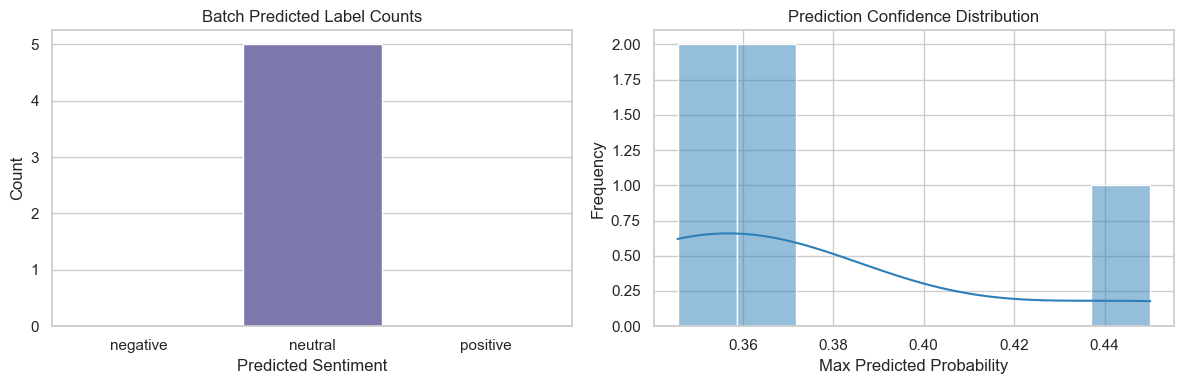

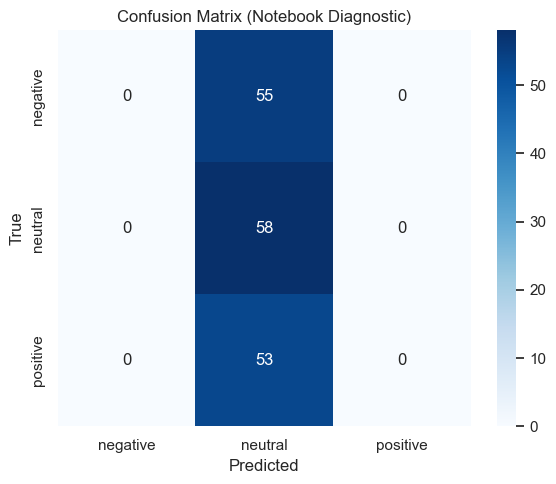

Classification Report (Notebook Diagnostic):
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        55
     neutral       0.35      1.00      0.52        58
    positive       0.00      0.00      0.00        53

    accuracy                           0.35       166
   macro avg       0.12      0.33      0.17       166
weighted avg       0.12      0.35      0.18       166



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

label_order = ["negative", "neutral", "positive"]

# 1) Batch prediction summary charts
results_df = pd.DataFrame(results)
proba_df = pd.DataFrame(results_df["probabilities"].tolist())

pred_counts = results_df["prediction"].value_counts().reindex(label_order, fill_value = 0)
confidence = proba_df.max(axis = 1)

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

sns.barplot(
    x = pred_counts.index,
    y = pred_counts.values,
    palette = ["#d95f02", "#7570b3", "#1b9e77"],
    ax = axes[0]
    )
axes[0].set_title("Batch Predicted Label Counts")
axes[0].set_xlabel("Predicted Sentiment")
axes[0].set_ylabel("Count")

sns.histplot(confidence, bins = 8, kde = True, color = "#2c7fb8", ax = axes[1])
axes[1].set_title("Prediction Confidence Distribution")
axes[1].set_xlabel("Max Predicted Probability")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 2) Quick confusion matrix on notebook dataset
eval_df = df[["text", "sentiment"]].dropna().copy()
true_labels = eval_df["sentiment"].map({0: "negative", 1: "neutral", 2: "positive"}).fillna(
    eval_df["sentiment"].astype(str).str.lower()
    )
valid_mask = true_labels.isin(label_order)
eval_df = eval_df[valid_mask]
true_labels = true_labels[valid_mask]

pred_labels = eval_df["text"].apply(predict_sentiment)
cm = confusion_matrix(true_labels, pred_labels, labels = label_order)

plt.figure(figsize = (6, 5))
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues",
    xticklabels = label_order,
    yticklabels = label_order
    )
plt.title("Confusion Matrix (Notebook Diagnostic)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("Classification Report (Notebook Diagnostic):")
print(classification_report(true_labels, pred_labels, labels = label_order, zero_division = 0))

In [9]:
pd.DataFrame(results)

,text,prediction,probabilities
0,"Мне очень понравился сервис, все было отлично.",neutral,"{'negative': 0.29272101585875604, 'neutral': 0..."
1,"Ужасное качество, сломалось через день.",neutral,"{'negative': 0.34554849366219936, 'neutral': 0..."
2,"Нормально, но ничего особенного.",neutral,"{'negative': 0.314681815201126, 'neutral': 0.3..."
3,"Я в восторге от покупки, ожидания превзойдены!",neutral,"{'negative': 0.28488316780162765, 'neutral': 0..."
4,"Не рекомендую, зря потратил деньги.",neutral,"{'negative': 0.2491233283474142, 'neutral': 0...."


### Interactive Demo

In [10]:
user_input = input("Введите текст для анализа тональности: ")  # Get user input
user_prediction = predict_sentiment(user_input)  # Predict sentiment for user input
print(f"Predicted Sentiment: {user_prediction}")

Predicted Sentiment: neutral
